# 残差网络实验
韩佳轩，23281106，计算机科学与技术学院

In [24]:
import torch
import torchvision
from torch.utils.data import DataLoader
import torch.nn as nn
from torch.nn import functional as F
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import pickle
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [25]:
torch.__version__

'2.8.0+cu129'

In [26]:
torch.cuda.is_available()

False

## 设置残差网络

In [27]:
class ResidualBlock(nn.Module):
    def __init__(self, inchannel, outchannel, stride=1):
        super(ResidualBlock, self).__init__()
        # 正常卷积部分，堆叠了两层卷积
        self.left = nn.Sequential(
            nn.Conv2d(inchannel, outchannel, 
                      kernel_size=3, stride=stride,
                      padding=1, bias=False),
            nn.BatchNorm2d(outchannel),
            nn.ReLU(inplace=True),
            nn.Conv2d(outchannel, outchannel, 
                      kernel_size=3, stride=1, 
                      padding=1, bias=False),
            nn.BatchNorm2d(outchannel)
        )
        
        # 如果上方卷积没有改变size和channel
        # 则不需要对输入进行变化，故 shortcut为空
        self.shortcut = nn.Sequential()
        # 如果上方卷积改变了size或channel
        # 则使用1x1卷积改变输入的size或channel，使其保持一致
        if stride != 1 or inchannel != outchannel:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inchannel, outchannel, 
                          kernel_size=1, stride=stride, 
                          bias=False),
                nn.BatchNorm2d(outchannel)
            )

    def forward(self, x):
        # 正常使用卷积操作
        out = self.left(x)
        # 将输入/变换shape后的输入与卷积的输出相加
        out += self.shortcut(x)
        # 经过激活函数后输出
        out = F.relu(out)
        return out

In [28]:
class ResNet(nn.Module):
    def __init__(self, ResidualBlock, num_classes=10):
        super(ResNet, self).__init__()
        self.inchannel = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        # 仅保留两个残差层以减少网络深度
        self.layer1 = self.make_layer(ResidualBlock, 64,  2, stride=1)
        self.layer2 = self.make_layer(ResidualBlock, 128, 2, stride=2)
        # 删除更深的 layer3 和 layer4，以降低模型复杂度
        # 使用自适应平均池化以兼容不同的特征图尺寸
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def make_layer(self, block, channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)   #strides=[1,1]
        layers = []
        for stride in strides:
            layers.append(block(self.inchannel, channels, stride))
            self.inchannel = channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        # 使用自适应池化，得到 (N, C, 1, 1)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

In [29]:
def train_epoch(net, data_loader, device):
    
    net.train() # 指定当前为训练模式
    train_batch_num = len(data_loader) # 记录共有多少个batch
    total_loss = 0 # 记录Loss
    correct = 0  # 记录共有多少个样本被正确分类
    sample_num = 0 # 记录样本总数
    
    # 遍历每个batch进行训练
    for batch_idx, (data, target) in enumerate(data_loader):
        # 将图片放入指定的device中
        data = data.to(device).float()
        # 将图片标签放入指定的device中
        target = target.to(device).long()
        # 将当前梯度清零
        optimizer.zero_grad()
        # 使用模型计算出结果
        output = net(data)
        # 计算损失
        loss = criterion(output, target)
        # 进行反向传播
        loss.backward()
        optimizer.step()
        # 累加Loss
        total_loss += loss.item()
        # 找出每个样本值最大的idx，即代表预测此图片属于哪个类别
        prediction = torch.argmax(output, 1)
        # 统计预测正确的类别数量
        correct += (prediction == target).sum().item()
        # 累加当前的样本总数
        sample_num += len(prediction)
    # 计算平均的loss与准确率
    loss = total_loss / train_batch_num
    acc = correct / sample_num
    return loss, acc

In [30]:
def test_epoch(net, data_loader, device):
    net.eval() # 指定当前模式为测试模式
    test_batch_num = len(data_loader)
    total_loss = 0
    correct = 0  
    sample_num = 0
    # 指定不进行梯度变化
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(data_loader):
            data = data.to(device).float()
            target = target.to(device).long()
            output = net(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            prediction = torch.argmax(output, 1)
            correct += (prediction == target).sum().item()
            sample_num += len(prediction)
    loss = total_loss / test_batch_num
    acc = correct / sample_num
    return loss, acc

## 导入数据

In [31]:
data_dir = './data' # 指定数据的位置
# 定义一个transform操作，用户将torch中的数据转换为可以输入到我们模型的形式
transform = transforms.Compose(
    [transforms.ToTensor(), # 首先将数据转换为Tensor
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]) # 将数据进行归一化，前一个参数代表mean，后一个代表std
# 获取cifar-10数据集并进行transform
cifar_train = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
cifar_test = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
# cifar-10数据集对应的10个类别
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
num_classes = 10 # 共十类
epochs = 50 # 训练多少轮
lr = 0.002 # 学习率
batch_size = 512 # batch大小
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
# 生成dataloader
cifar_trainloader = torch.utils.data.DataLoader(cifar_train, batch_size=batch_size,
                                                shuffle=True, num_workers=0)
cifar_testloader = torch.utils.data.DataLoader(cifar_test, batch_size=512,
                                               shuffle=True, num_workers=0)
# 初始化模型
net = ResNet(ResidualBlock).to(device)
# 使用多元交叉熵损失
criterion = nn.CrossEntropyLoss()
# 使用Adam优化器
optimizer = optim.Adam(net.parameters(), lr=lr)

Using device: cpu


## 模型训练

In [32]:
# 存储每一个epoch的loss与acc的变化，便于后面可视化
train_loss_list = []
train_acc_list = []
test_loss_list = []
test_acc_list = []

# 进行训练
for epoch in range(epochs):
    # 在训练集上训练
    train_loss, train_acc = train_epoch(net, data_loader=cifar_trainloader, device=device)
    # 在测试集上验证
    test_loss, test_acc = test_epoch(net, data_loader=cifar_testloader, device=device)
    # 保存各个指标
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    test_loss_list.append(test_loss)
    test_acc_list.append(test_acc)
    print(f"epoch:{epoch}\t train_loss:{train_loss:.4f} \t"
          f"train_acc:{train_acc} \t"
          f"test_loss:{test_loss:.4f} \t test_acc:{test_acc}")

epoch:0	 train_loss:1.5272 	train_acc:0.43932 	test_loss:1.4393 	 test_acc:0.4662
epoch:1	 train_loss:1.0908 	train_acc:0.60874 	test_loss:1.2213 	 test_acc:0.5724
epoch:2	 train_loss:0.8973 	train_acc:0.6807 	test_loss:0.9277 	 test_acc:0.6675
epoch:3	 train_loss:0.7794 	train_acc:0.72558 	test_loss:1.3739 	 test_acc:0.5743
epoch:4	 train_loss:0.6893 	train_acc:0.75732 	test_loss:0.9856 	 test_acc:0.6557
epoch:5	 train_loss:0.6148 	train_acc:0.785 	test_loss:0.9354 	 test_acc:0.6837
epoch:6	 train_loss:0.5469 	train_acc:0.81168 	test_loss:0.7465 	 test_acc:0.75
epoch:7	 train_loss:0.4907 	train_acc:0.83144 	test_loss:0.6891 	 test_acc:0.7687
epoch:8	 train_loss:0.4406 	train_acc:0.84698 	test_loss:0.6317 	 test_acc:0.7869
epoch:9	 train_loss:0.3900 	train_acc:0.86428 	test_loss:0.6205 	 test_acc:0.7917
epoch:10	 train_loss:0.3389 	train_acc:0.88304 	test_loss:0.5854 	 test_acc:0.8041
epoch:11	 train_loss:0.3129 	train_acc:0.89184 	test_loss:0.6454 	 test_acc:0.7911
epoch:12	 train_los

KeyboardInterrupt: 

## 实验结果展示

In [33]:
res = [train_loss_list, train_acc_list, test_loss_list,test_acc_list]

In [34]:
with open('resnet-18.pkl', 'wb') as f:
    pickle.dump(res, f)

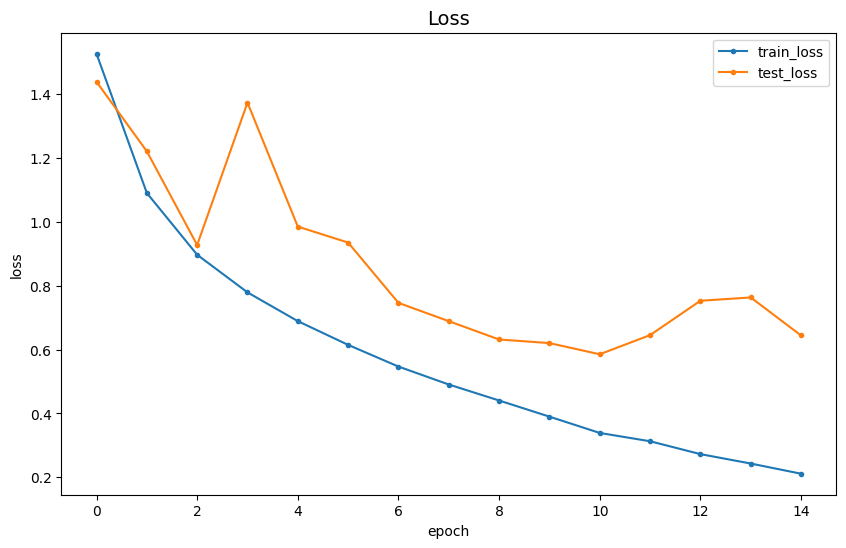

In [35]:
plt.figure(figsize=(10, 6))
train, = plt.plot(train_loss_list,'.-',label='train_loss')
test, = plt.plot(test_loss_list,'.-',label='test_loss')
plt.title("Loss",fontsize=14)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend([train,test],["train_loss", "test_loss"],loc='upper right')
plt.show()

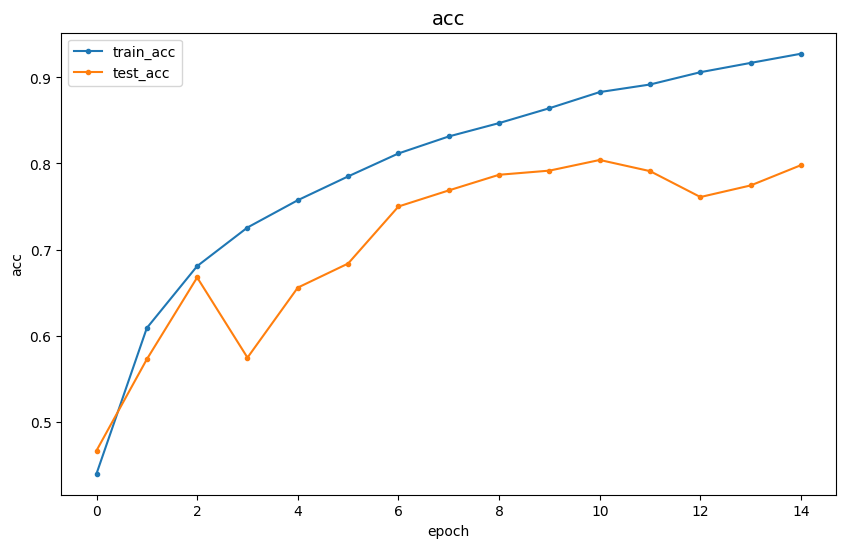

In [36]:
plt.figure(figsize=(10, 6))
train, = plt.plot(train_acc_list,'.-',label='train_acc')
test, = plt.plot(test_acc_list,'.-',label='test_acc')
plt.title("acc",fontsize=14)
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend([train,test],["train_acc", "test_acc"],loc='upper left')
plt.show()

In [37]:
max(test_acc_list)

0.8041